# M2-B1 — Audit Banque Eckmühl + industrialisation pipe

> **Mission** : auditer le dataset German Credit fourni par Eckmühl, identifier
> les risques qualité et éthiques, construire un Pipeline scikit-learn
> réutilisable, persister en Parquet, documenter dans une datasheet.

Auteur·rice : `Théo / Copilot` — Date : `16/06/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser la cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path
import importlib
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append("..")
sys.path.append("../src")

import preprocess as pp
from contract_test import contract_test_pipeline

RANDOM_STATE = 42
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "german_credit_raw.csv"
CLEAN_PATH = DATA_DIR / "german_credit_clean.parquet"

sns.set_theme(style="whitegrid")

## 1. Découverte du dataset (~30 min)

Chargement, types, premier aperçu. Repérage de la cible et des variables
sensibles évidentes (`age`, `personal_status_sex`, `foreign_worker`).

In [2]:
df = pd.read_csv(RAW_PATH)

# Vue rapide du dataset
display(df.head())
display(df.describe(include="all").transpose())

target_column = "credit_risk"
feature_columns = [col for col in df.columns if col != target_column]

sensitive_features = ["age", "personal_status_sex", "foreign_worker"]

summary = pd.DataFrame(
    {
        "element": [
            "source",
            "target",
            "n_features",
            "features",
            "sensitive_features",
            "notes",
        ],
        "value": [
            "UCI Statlog (German Credit Data)",
            target_column,
            len(feature_columns),
            ", ".join(feature_columns),
            ", ".join(sensitive_features),
            "personal_status_sex est une variable composite (genre + statut civil), anti-pattern pour l'audit d'equite.",
        ],
    }
)

assert len(feature_columns) == 20, "Le dataset doit contenir 20 features hors cible."
display(summary)

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,n_existing_credits,job,n_people_liable,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account / other credits existing,radio/TV,1169,unknown / no savings,>= 7 years,4,male single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered",yes,good_credit
1,0 to 200 DM,48,existing credits paid back duly,radio/TV,5951,< 100 DM,1-4 years,2,female divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,bad_credit
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4-7 years,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good_credit
3,< 0 DM,42,existing credits paid back duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male single,guarantor,...,savings agreement / life insurance,45,none,for free,1,skilled employee / official,2,none,yes,good_credit
4,< 0 DM,24,delay in paying off in past,car (new),4870,< 100 DM,1-4 years,3,male single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,bad_credit


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_account_status,1000,4,no checking account,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
credit_history,1000,5,existing credits paid back duly,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,radio/TV,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
savings_account,1000,5,< 100 DM,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_since,1000,5,1-4 years,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate_pct_income,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
personal_status_sex,1000,4,male single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors,1000,3,none,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,element,value
0,source,UCI Statlog (German Credit Data)
1,target,credit_risk
2,n_features,20
3,features,"checking_account_status, duration_months, cred..."
4,sensitive_features,"age, personal_status_sex, foreign_worker"
5,notes,personal_status_sex est une variable composite...


### Synthèse Tâche 1 (CSV + doc UCI)

Référence UCI: Statlog (German Credit Data), 1000 lignes, 20 features + 1 cible.

- Cible: `credit_risk` (`good_credit` / `bad_credit`)
- Nombre de features explicatives: `20`

Features:
`checking_account_status`, `duration_months`, `credit_history`, `purpose`, `credit_amount`, `savings_account`, `employment_since`, `installment_rate_pct_income`, `personal_status_sex`, `other_debtors`, `residence_since_years`, `property`, `age`, `other_installment_plans`, `housing`, `n_existing_credits`, `job`, `n_people_liable`, `telephone`, `foreign_worker`

Variables sensibles évidentes à suivre pour l'audit éthique:
- `age`
- `personal_status_sex` (variable composite genre + statut civil, anti-pattern documenté)
- `foreign_worker`

## 2. Audit qualité (~1 h)

Manquants, outliers, types, cohérence des modalités. **Au moins 4
visualisations** : distribution cible, distribution `age`, distribution
`credit_amount`, crosstab sensible (ex. `credit_risk` × `personal_status_sex`).

> *Quels problèmes de qualité ai-je identifiés ?* — court paragraphe à
> rédiger ici.

Le dataset est globalement propre sur les manquants explicites (`NaN`) mais presente des points d'attention: 

- (1) une asymetrie forte de `credit_amount` avec des valeurs extremes (outliers), 
- (2) des variables ordinales encodees en texte (ex. `savings_account`, `employment_since`) qui exigent un ordre explicite dans le pipeline, 
- (3) une variable composite `personal_status_sex` qui melange deux dimensions semantiques, ce qui complique les controles de coherence et d'equite,
- (4) un desequilibre de la cible (`good_credit` majoritaire) a prendre en compte pour l'evaluation des modeles.

In [3]:
# Manquants, types et cardinalites
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)

dtype_table = (
    df.dtypes.astype(str)
    .rename("dtype")
    .to_frame()
    .assign(n_unique=df.nunique(dropna=False).values)
)

quality_table = pd.concat(
    [
        missing_counts.rename("missing_count"),
        missing_pct.rename("missing_pct"),
        dtype_table,
    ],
    axis=1,
).sort_values(["missing_count", "n_unique"], ascending=[False, True])

display(quality_table)

# Cohérence des modalités (trim + casse)
cat_cols = df.select_dtypes(include="object").columns.tolist()
coherence_rows = []
for col in cat_cols:
    s = df[col].dropna().astype(str)
    leading_trailing_spaces = int((s != s.str.strip()).sum())
    has_case_inconsistency = s.str.lower().nunique() < s.nunique()
    coherence_rows.append(
        {
            "column": col,
            "n_unique": int(df[col].nunique(dropna=False)),
            "leading_trailing_spaces": leading_trailing_spaces,
            "case_inconsistency": bool(has_case_inconsistency),
        }
    )

coherence_df = pd.DataFrame(coherence_rows).sort_values("n_unique", ascending=False)
display(coherence_df)

,missing_count,missing_pct,dtype,n_unique
foreign_worker,0,0.0,object,2
telephone,0,0.0,object,2
n_people_liable,0,0.0,int64,2
credit_risk,0,0.0,object,2
housing,0,0.0,object,3
other_installment_plans,0,0.0,object,3
other_debtors,0,0.0,object,3
checking_account_status,0,0.0,object,4
property,0,0.0,object,4
job,0,0.0,object,4


,column,n_unique,leading_trailing_spaces,case_inconsistency
2,purpose,10,0,False
1,credit_history,5,0,False
3,savings_account,5,0,False
4,employment_since,5,0,False
0,checking_account_status,4,0,False
5,personal_status_sex,4,0,False
7,property,4,0,False
10,job,4,0,False
6,other_debtors,3,0,False
8,other_installment_plans,3,0,False


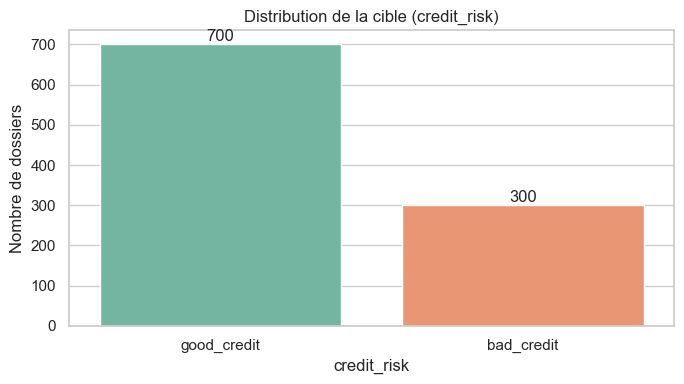

In [4]:
# Visualisation 1: distribution de la cible
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x="credit_risk", hue="credit_risk", palette="Set2", legend=False)
plt.title("Distribution de la cible (credit_risk)")
plt.xlabel("credit_risk")
plt.ylabel("Nombre de dossiers")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

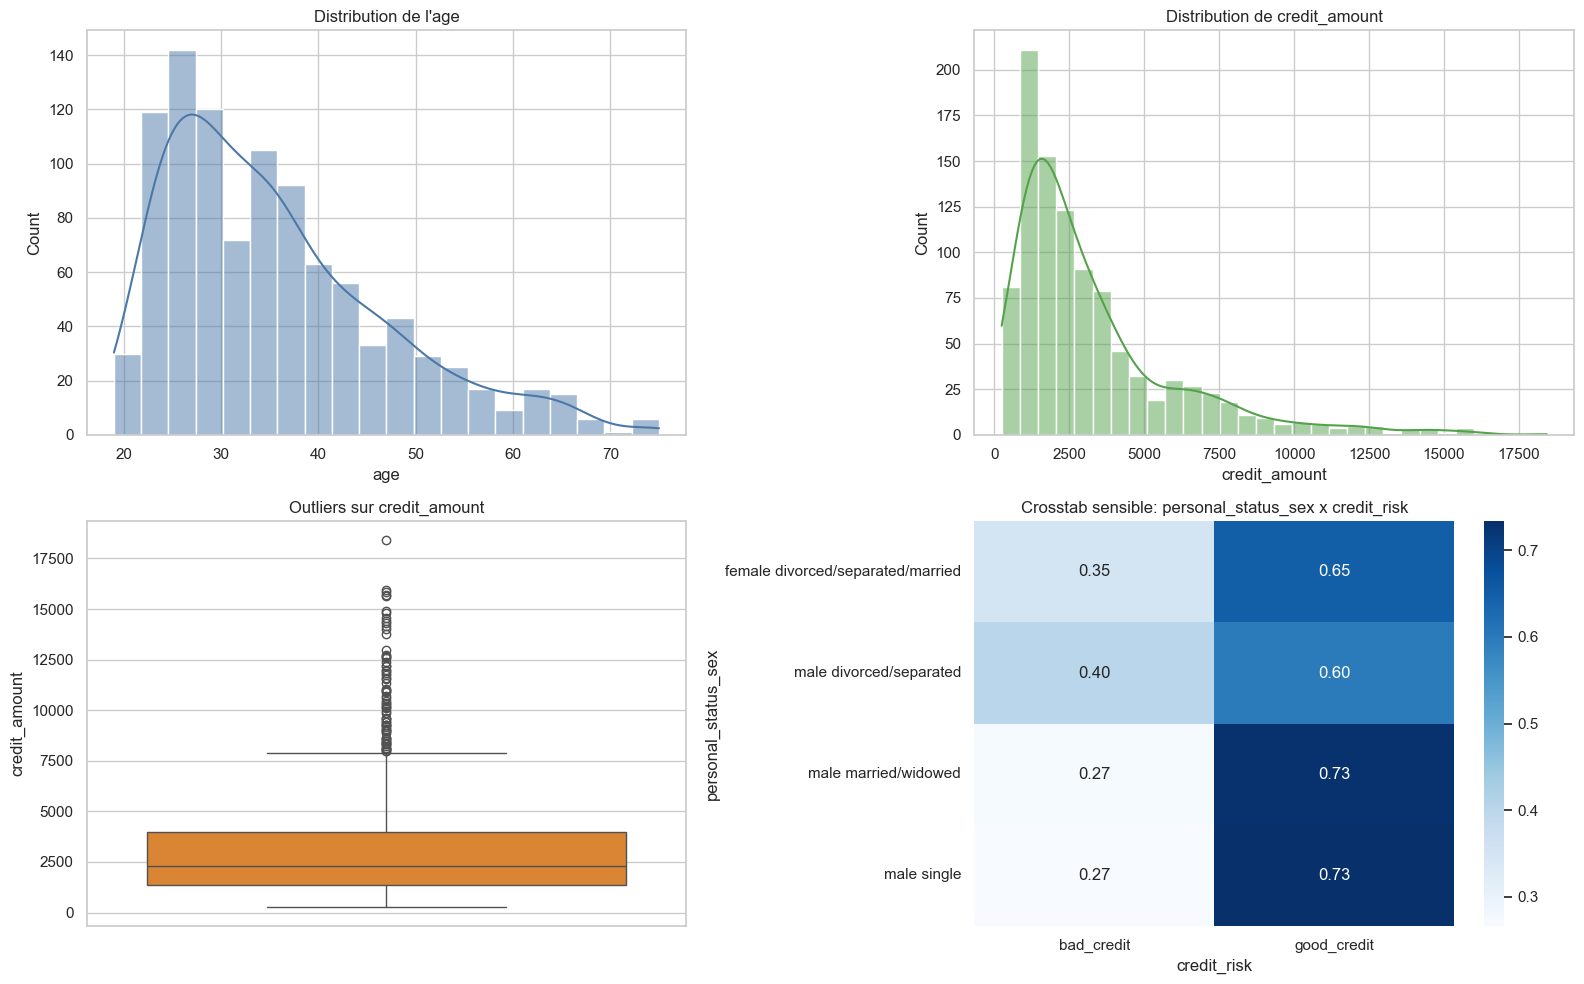

,metric,value
0,missing_total,0.0
1,outlier_rate_credit_amount_iqr_pct,7.2
2,min_age,19.0
3,max_age,75.0
4,n_modalites_personal_status_sex,4.0


In [5]:
# Visualisations 2/3/4/5: age, distribution credit_amount, outliers credit_amount, crosstab sensible
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0, 0], color="#4c78a8")
axes[0, 0].set_title("Distribution de l'age")
axes[0, 0].set_xlabel("age")

sns.histplot(data=df, x="credit_amount", bins=30, kde=True, ax=axes[0, 1], color="#54a24b")
axes[0, 1].set_title("Distribution de credit_amount")
axes[0, 1].set_xlabel("credit_amount")

sns.boxplot(data=df, y="credit_amount", ax=axes[1, 0], color="#f58518")
axes[1, 0].set_title("Outliers sur credit_amount")
axes[1, 0].set_ylabel("credit_amount")

ct = pd.crosstab(df["personal_status_sex"], df["credit_risk"], normalize="index")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", ax=axes[1, 1])
axes[1, 1].set_title("Crosstab sensible: personal_status_sex x credit_risk")
axes[1, 1].set_xlabel("credit_risk")
axes[1, 1].set_ylabel("personal_status_sex")

plt.tight_layout()
plt.show()

# Indicateurs numeriques complements pour les outliers (regle IQR)
q1 = df["credit_amount"].quantile(0.25)
q3 = df["credit_amount"].quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_rate = ((df["credit_amount"] < low) | (df["credit_amount"] > high)).mean() * 100

quality_flags = pd.DataFrame(
    {
        "metric": [
            "missing_total",
            "outlier_rate_credit_amount_iqr_pct",
            "min_age",
            "max_age",
            "n_modalites_personal_status_sex",
        ],
        "value": [
            int(df.isna().sum().sum()),
            round(outlier_rate, 2),
            int(df["age"].min()),
            int(df["age"].max()),
            int(df["personal_status_sex"].nunique()),
        ],
    }
)

display(quality_flags)

## 3. Audit éthique léger (~1 h)

Déséquilibre cible + **disparate impact** sur au moins 2 variables sensibles.
Règle des 4/5 : `DI < 0.8` ou `> 1.25` → signal.

> *Biais structurels détectés (constat court)* : la cible est déséquilibrée (~70 % `good_credit`, ~30 % `bad_credit`), ce qui peut masquer les erreurs sur la classe minoritaire. Le calcul du DI montre des écarts de probabilité d'obtenir `good_credit` entre groupes sur `foreign_worker` et sur `personal_status_sex`; dès que le DI sort de [0.8 ; 1.25], on considère un signal de biais à investiguer. La variable `personal_status_sex` étant composite (genre + statut civil), l'interprétation causale est limitée.

⚠️ Pas de mitigation à ce stade — on documente, on alerte. La mitigation,
c'est M7.

In [6]:
# Audit ethique: desequilibre cible + DI sur foreign_worker
POSITIVE_LABEL = "good_credit"

target_dist = (
    df["credit_risk"]
    .value_counts(normalize=True)
    .rename("ratio")
    .mul(100)
    .round(2)
    .rename_axis("credit_risk")
    .reset_index()
)
display(target_dist)

# Base commune pour les calculs DI
def compute_di(frame: pd.DataFrame, sensitive_col: str, positive_label: str = POSITIVE_LABEL) -> pd.Series:
    group_sizes = frame[sensitive_col].value_counts(dropna=False)
    majority_group = group_sizes.idxmax()
    minority_group = group_sizes.idxmin()

    positive_rates = (
        frame.groupby(sensitive_col)["credit_risk"]
        .apply(lambda s: (s == positive_label).mean())
        .sort_values(ascending=False)
    )

    p_minority = float(positive_rates.loc[minority_group])
    p_majority = float(positive_rates.loc[majority_group])
    di = p_minority / p_majority if p_majority > 0 else np.nan
    di_flag = (di < 0.8) or (di > 1.25)

    return pd.Series(
        {
            "sensitive_var": sensitive_col,
            "minority_group": minority_group,
            "majority_group": majority_group,
            "p_positive_minority": round(p_minority, 4),
            "p_positive_majority": round(p_majority, 4),
            "di": round(di, 4),
            "bias_signal_4_5_rule": di_flag,
        }
    )

foreign_worker_di = compute_di(df, "foreign_worker")
display(foreign_worker_di.to_frame(name="value"))

foreign_worker_rates = (
    df.groupby("foreign_worker")["credit_risk"]
    .apply(lambda s: (s == POSITIVE_LABEL).mean())
    .rename("p_good_credit")
    .round(4)
    .reset_index()
)
display(foreign_worker_rates)

,credit_risk,ratio
0,good_credit,70.0
1,bad_credit,30.0


,value
sensitive_var,foreign_worker
minority_group,no
majority_group,yes
p_positive_minority,0.8919
p_positive_majority,0.6926
di,1.2877
bias_signal_4_5_rule,True


,foreign_worker,p_good_credit
0,no,0.8919
1,yes,0.6926


In [7]:
# DI sur personal_status_sex (variable composite)
personal_status_di = compute_di(df, "personal_status_sex")
display(personal_status_di.to_frame(name="value"))

personal_status_rates = (
    df.groupby("personal_status_sex")["credit_risk"]
    .apply(lambda s: (s == POSITIVE_LABEL).mean())
    .sort_values(ascending=False)
    .rename("p_good_credit")
    .round(4)
    .reset_index()
)
display(personal_status_rates)

# Tableau recapitulatif des 2 DI demandes
di_summary = pd.DataFrame([foreign_worker_di, personal_status_di])
display(di_summary)

,value
sensitive_var,personal_status_sex
minority_group,male divorced/separated
majority_group,male single
p_positive_minority,0.6
p_positive_majority,0.7336
di,0.8179
bias_signal_4_5_rule,False


,personal_status_sex,p_good_credit
0,male single,0.7336
1,male married/widowed,0.7283
2,female divorced/separated/married,0.6484
3,male divorced/separated,0.6000


,sensitive_var,minority_group,majority_group,p_positive_minority,p_positive_majority,di,bias_signal_4_5_rule
0,foreign_worker,no,yes,0.8919,0.6926,1.2877,True
1,personal_status_sex,male divorced/separated,male single,0.6000,0.7336,0.8179,False


## 4. Choix de prétraitement (~30 min)

Pour chaque feature, décide : numérique (impute + scale), ordinale
(impute + ordinal encoding **avec ordre**), catégorielle (impute + onehot),
ou exclue (justifie).

Remplis les listes `NUMERIC_FEATURES`, `ORDINAL_FEATURES`,
`CATEGORICAL_FEATURES` dans `src/preprocess.py`.

### Glossaire explicatif (pour le moi du futur)

| Terme | Explication simple |
|---|---|
| Pretraitement | Transformations appliquees aux donnees avant le modele. |
| Feature | Colonne d'entree utilisee pour predire la cible. |
| Imputation | Remplacer une valeur manquante (`NaN`) par une valeur de remplacement. |
| Mediane | Valeur centrale d'une variable numerique, robuste aux valeurs extremes. |
| Modalite la plus frequente | Categorie la plus observee dans une colonne. |
| Variable numerique continue | Variable chiffrable sur une echelle (ex. `credit_amount`). |
| Variable categorielle nominale | Categories sans ordre naturel (ex. `housing`). |
| Variable categorielle ordinale | Categories avec ordre naturel (ex. anciennete d'emploi). |
| OneHotEncoder | Cree une colonne 0/1 par modalite. |
| OrdinalEncoder | Convertit des modalites ordonnees en nombres ordonnes. |
| Target Encoding | Encode les categories avec une statistique de la cible; puissant mais risque de fuite. |
| Normalisation (StandardScaler) | Met les numeriques sur la meme echelle (moyenne 0, ecart-type 1). |
| Pipeline | Chaine automatique de transformations executees dans le bon ordre. |
| Fuite de donnees (data leakage) | Information du test qui influence l'entrainement, ce qui fausse l'evaluation. |

### 4.1 Strategie d'imputation par feature

**Numeriques** (`duration_months`, `credit_amount`, `installment_rate_pct_income`, `residence_since_years`, `age`, `n_existing_credits`, `n_people_liable`)  
- Imputation: `SimpleImputer(strategy="median")`.
- Justification: robuste aux valeurs extremes (notamment `credit_amount`) et conserve l'ordre des grandeurs.

**Categorielles nominales** (`checking_account_status`, `credit_history`, `purpose`, `personal_status_sex`, `other_debtors`, `property`, `other_installment_plans`, `housing`, `job`, `telephone`, `foreign_worker`)  
- Imputation: `SimpleImputer(strategy="most_frequent")`.
- Justification: preserve des modalites valides sans inventer de categorie artificielle.

**Categorielles ordinales** (`savings_account`, `employment_since`)  
- Imputation: `SimpleImputer(strategy="most_frequent")` avant encodage ordinal.
- Justification: compatible avec un ordre explicite des niveaux ensuite.

### 4.2 Choix d'encodage

**OneHotEncoder pour les nominales (faible cardinalite)**  
- Colonnes: `checking_account_status`, `credit_history`, `purpose`, `personal_status_sex`, `other_debtors`, `property`, `other_installment_plans`, `housing`, `job`, `telephone`, `foreign_worker`.
- Pourquoi: pas d'ordre naturel entre modalites; One-Hot evite d'introduire une distance arbitraire.

**OrdinalEncoder pour les ordinales**  
- Colonnes: `savings_account`, `employment_since`.
- Pourquoi: ces variables portent un ordre metier.
- Ordres proposes:
  - `savings_account`: `< 100 DM` < `100-500 DM` < `500-1000 DM` < `>= 1000 DM` < `unknown / no savings`
  - `employment_since`: `unemployed` < `< 1 year` < `1-4 years` < `4-7 years` < `>= 7 years`

Cette separation (nominale vs ordinale) limite les biais de representation et reste interpretable.

### 4.3 Pourquoi on evite le Target Encoding ici

Le **Target Encoding** remplace chaque modalite par une statistique de la cible (ex. moyenne de `good_credit`).

Pourquoi on l'evite dans ce brief:
- Risque eleve de fuite de donnees si l'encodage est calcule sans schema strict train/validation.
- Dataset petit (1000 lignes): les estimations par modalite peuvent etre instables.
- Objectif pedagogique du module: pipeline simple, interpretable et robuste (`OneHot`/`Ordinal`).
- Variables sensibles presentes: injecter directement l'information cible dans l'encodage complique la lecture des biais.

Conclusion: Target Encoding possible dans d'autres contextes, mais non prioritaire ni necessaire ici.

### 4.4 Normalisation des numeriques

**Choix:** `StandardScaler` sur les variables numeriques continues.

- Colonnes: `duration_months`, `credit_amount`, `installment_rate_pct_income`, `residence_since_years`, `age`, `n_existing_credits`, `n_people_liable`.
- Effet: centrage-reduction (moyenne 0, ecart-type 1).
- Justification:
  - met les echelles au meme niveau,
  - utile pour de nombreux modeles sensibles a l'echelle (regression logistique, SVM, KNN),
  - facilite la stabilite numerique du pipeline.

Note: l'imputation est faite avant la normalisation dans le pipeline pour eviter les erreurs sur valeurs manquantes.

### 4.5 Tache 5 bis - variable `customer_segment` (complement Eckmuhl)

- Le fichier `german_credit_supplement.csv` apporte une colonne `customer_segment` (meme ordre de lignes), jointe **par position**.
- Choix retenu: **variable ordinale** avec ordre `basic < plus < premium < private`.
- Justification: ce segment represente un tier commercial croissant, il y a donc une notion d'ordre metier.
- Gestion des manquants (~4 %): imputation par modalite la plus frequente dans la branche ordinale du pipeline.
- Impact sur le preprocesseur: avec `OrdinalEncoder`, cette variable ajoute **+1 dimension** en sortie.

Reflexe ethique (a reporter dans audit.md): `customer_segment` peut etre un proxy du niveau de richesse; prudence avant usage en scoring credit pour eviter une discrimination socio-economique indirecte.

## 5. Industrialisation Pipeline (~1 h 15)

Une fois `src/preprocess.py` complété, fitte le pipeline et sauve-le.

### 🎓 Pourquoi un `Pipeline` ? (définition — la fuite de données)

Tu pourrais imputer/encoder/scaler « à la main » en Pandas. On enferme tout
dans un `Pipeline` parce qu'un préprocesseur **apprend des paramètres sur les
données** : `SimpleImputer` retient une médiane, `StandardScaler` une moyenne
et un écart-type, `OneHotEncoder` la liste des modalités.

**Fuite de données** (*data leakage*) = laisser de l'information du jeu de
**test** influencer la préparation du jeu d'**entraînement** — typiquement
calculer ces paramètres sur *tout* le dataset avant de le splitter. Symptôme :
des scores de validation **anormalement optimistes** qui s'effondrent en prod.

Le `Pipeline` est l'outil qui rend l'étanchéité automatique : un seul `fit` sur
le train propage la discipline à toutes les transformations. **Ici tu n'as pas
de split** (on produit juste un dataset propre) → `fit_transform` sur tout le
dataset est OK. **Réflexe à garder** : *dès qu'un modèle entre en jeu, le
préprocesseur ne se `fit` que sur le train.* → mise en œuvre en **M4-B1**.

In [8]:
importlib.reload(pp)

X, y = pp.load_dataset(RAW_PATH)
preprocessor = pp.build_preprocessor()
X_transformed = preprocessor.fit_transform(X)

shape_summary = pd.DataFrame(
    {
        "metric": [
            "n_rows",
            "n_features_input",
            "n_features_output",
            "estimated_previous_output_without_customer_segment",
            "delta_vs_previous_estimate",
        ],
        "value": [
            X.shape[0],
            X.shape[1],
            X_transformed.shape[1],
            X_transformed.shape[1] - 1,
            1,
        ],
    }
)

display(shape_summary)

display(
    pd.DataFrame(
        {
            "customer_segment_missing_pct": [
                round(X["customer_segment"].isna().mean() * 100, 2)
            ]
        }
    )
)

,metric,value
0,n_rows,1000
1,n_features_input,21
2,n_features_output,54
3,estimated_previous_output_without_customer_seg...,53
4,delta_vs_previous_estimate,1


,customer_segment_missing_pct
0,3.7


In [9]:
import joblib
joblib.dump(preprocessor, "../src/pipeline.joblib", compress=3)

['../src/pipeline.joblib']

## 6. Persistance Parquet + datasheet (~45 min)

Sauve le dataset propre en Parquet (pyarrow) et complète `datasheet.md`
(7 sections Gebru, schéma documenté dans *Composition*).

In [10]:
# Creation d'un dataset propre et persistance Parquet (pyarrow)
X_clean, y_clean = pp.load_dataset(RAW_PATH)

df_clean = X_clean.copy()
# On applique ici l'imputation modale de customer_segment pour livrer un fichier sans manquants.
df_clean["customer_segment"] = df_clean["customer_segment"].fillna(
    df_clean["customer_segment"].mode(dropna=True).iloc[0]
)
df_clean["credit_risk"] = y_clean.map({0: "good_credit", 1: "bad_credit"})

df_clean.to_parquet(CLEAN_PATH, engine="pyarrow", compression="snappy", index=False)

display(
    pd.DataFrame(
        {
            "saved_path": [str(CLEAN_PATH)],
            "shape": [df_clean.shape],
            "missing_total": [int(df_clean.isna().sum().sum())],
        }
    )
)

,saved_path,shape,missing_total
0,..\data\german_credit_clean.parquet,"(1000, 22)",0


In [11]:
# Verification relecture
df_back = pd.read_parquet(CLEAN_PATH)

verification = pd.DataFrame(
    {
        "metric": [
            "rows",
            "cols",
            "missing_total",
            "csv_size_kb",
            "parquet_size_kb",
            "compression_ratio_csv_over_parquet",
        ],
        "value": [
            df_back.shape[0],
            df_back.shape[1],
            int(df_back.isna().sum().sum()),
            round(RAW_PATH.stat().st_size / 1024, 1),
            round(CLEAN_PATH.stat().st_size / 1024, 1),
            round((RAW_PATH.stat().st_size / CLEAN_PATH.stat().st_size), 1),
        ],
    }
)

display(verification)
display(df_back.head())

,metric,value
0,rows,1000.0
1,cols,22.0
2,missing_total,0.0
3,csv_size_kb,207.6
4,parquet_size_kb,28.0
5,compression_ratio_csv_over_parquet,7.4


,duration_months,credit_amount,installment_rate_pct_income,residence_since_years,age,n_existing_credits,n_people_liable,savings_account,employment_since,customer_segment,...,purpose,personal_status_sex,other_debtors,property,other_installment_plans,housing,job,telephone,foreign_worker,credit_risk
0,6,1169,4,4,67,2,1,unknown / no savings,>= 7 years,basic,...,radio/TV,male single,none,real estate,none,own,skilled employee / official,"yes, registered",yes,good_credit
1,48,5951,2,2,22,1,1,< 100 DM,1-4 years,basic,...,radio/TV,female divorced/separated/married,none,real estate,none,own,skilled employee / official,none,yes,bad_credit
2,12,2096,2,3,49,1,2,< 100 DM,4-7 years,plus,...,education,male single,none,real estate,none,own,unskilled resident,none,yes,good_credit
3,42,7882,2,4,45,1,2,< 100 DM,4-7 years,basic,...,furniture/equipment,male single,guarantor,savings agreement / life insurance,none,for free,skilled employee / official,none,yes,good_credit
4,24,4870,3,4,53,2,2,< 100 DM,1-4 years,basic,...,car (new),male single,none,unknown / no property,none,for free,skilled employee / official,none,yes,bad_credit


## 6 bis. Validation avec les methodes de `contract_test.py`

On reutilise la fonction `contract_test_pipeline` du script de contrat pour verifier, dans le notebook, que le pipeline respecte bien le contrat attendu (lignes preservees, pas de NaN, determinisme, dimension de sortie stable).

In [12]:
MODEL_PATH = Path("../src/pipeline.joblib")
DATA_PATH = Path("../data/german_credit_raw.csv")
EXPECTED_N_FEATURES = 54

X_contract, _ = pp.load_dataset(DATA_PATH)
contract_test_pipeline(
    model_path=MODEL_PATH,
    x_sample=X_contract.head(5),
    expected_n_features=EXPECTED_N_FEATURES,
)

Contract test OK — 5 lignes préservées, 54 colonnes en sortie, aucun NaN, transformation déterministe.


## 7. Synthèse audit.md (~30 min)

Complète `audit.md` : verdict qualité (3-5 problèmes) + verdict éthique
(2-3 alertes) + recommandations. Lisible par le DPO Klaus Eichmann
(pas de jargon scikit-learn).